# Homework 2

Name: Janya Bhaskar

USC ID: 6742897322

## Problem 1

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


### b
#### i

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_excel('Folds5x2_pp.xlsx', sheet_name='Sheet1')
print(df.shape)
print(df.head())

Saving Folds5x2_pp.xlsx to Folds5x2_pp (1).xlsx
(9568, 5)
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


There are 9568 rows and 5 columns. The rows represent hourly observations at the plant. 4 of the columns are predictors, and the last is a response.

#### ii

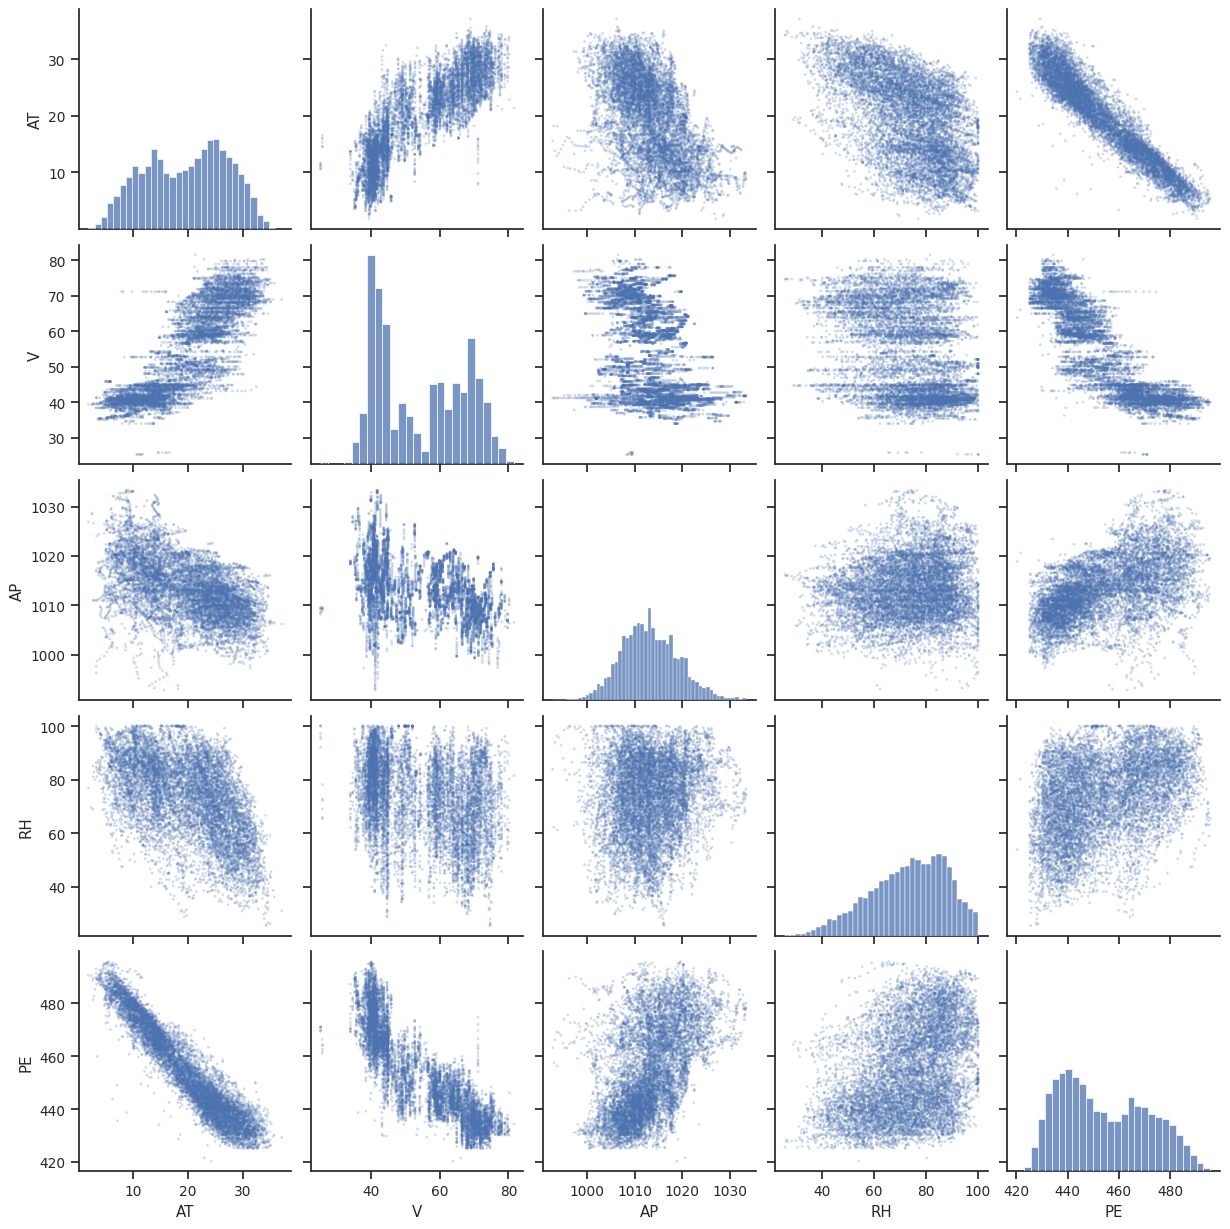

In [4]:
sns.set_theme(style='ticks', font_scale=0.9)
g = sns.pairplot(
    df,
    diag_kind='hist',
    plot_kws={'s': 4, 'alpha': 0.25, 'edgecolor': 'none'}
)
plt.show()

#### iii

In [6]:
summary = pd.DataFrame({
    'Mean':   df.mean(),
    'Median': df.median(),
    'Min':    df.min(),
    'Max':    df.max(),
    'Range':  df.max() - df.min(),
    'Q1':     df.quantile(0.25),
    'Q3':     df.quantile(0.75),
    'IQR':    df.quantile(0.75) - df.quantile(0.25),
}).round(3)
print(summary)

        Mean    Median     Min      Max  Range        Q1       Q3     IQR
AT    19.651    20.345    1.81    37.11  35.30    13.510    25.72  12.210
V     54.306    52.080   25.36    81.56  56.20    41.740    66.54  24.800
AP  1013.259  1012.940  992.89  1033.30  40.41  1009.100  1017.26   8.160
RH    73.309    74.975   25.56   100.16  74.60    63.328    84.83  21.502
PE   454.365   451.550  420.26   495.76  75.50   439.750   468.43  28.680


### c

In [8]:
import statsmodels.api as sm

In [11]:
import numpy as np

===== PE ~ AT =====
  coefficient   : -2.1713
  intercept     : 497.0341
  p-value       : 0
  R-squared     : 0.8989
  t-statistic   : -291.72

AT: 42 points with |studentized residual| > 3, max Cook's distance = 0.0143

===== PE ~ V =====
  coefficient   : -1.1681
  intercept     : 517.8015
  p-value       : 0
  R-squared     : 0.7565
  t-statistic   : -172.40

V: 33 points with |studentized residual| > 3, max Cook's distance = 0.0032

===== PE ~ AP =====
  coefficient   : 1.4899
  intercept     : -1055.2610
  p-value       : 0
  R-squared     : 0.2688
  t-statistic   : 59.30

AP: 30 points with |studentized residual| > 3, max Cook's distance = 0.0082

===== PE ~ RH =====
  coefficient   : 0.4557
  intercept     : 420.9618
  p-value       : 0
  R-squared     : 0.1519
  t-statistic   : 41.40

RH: 2 points with |studentized residual| > 3, max Cook's distance = 0.0021



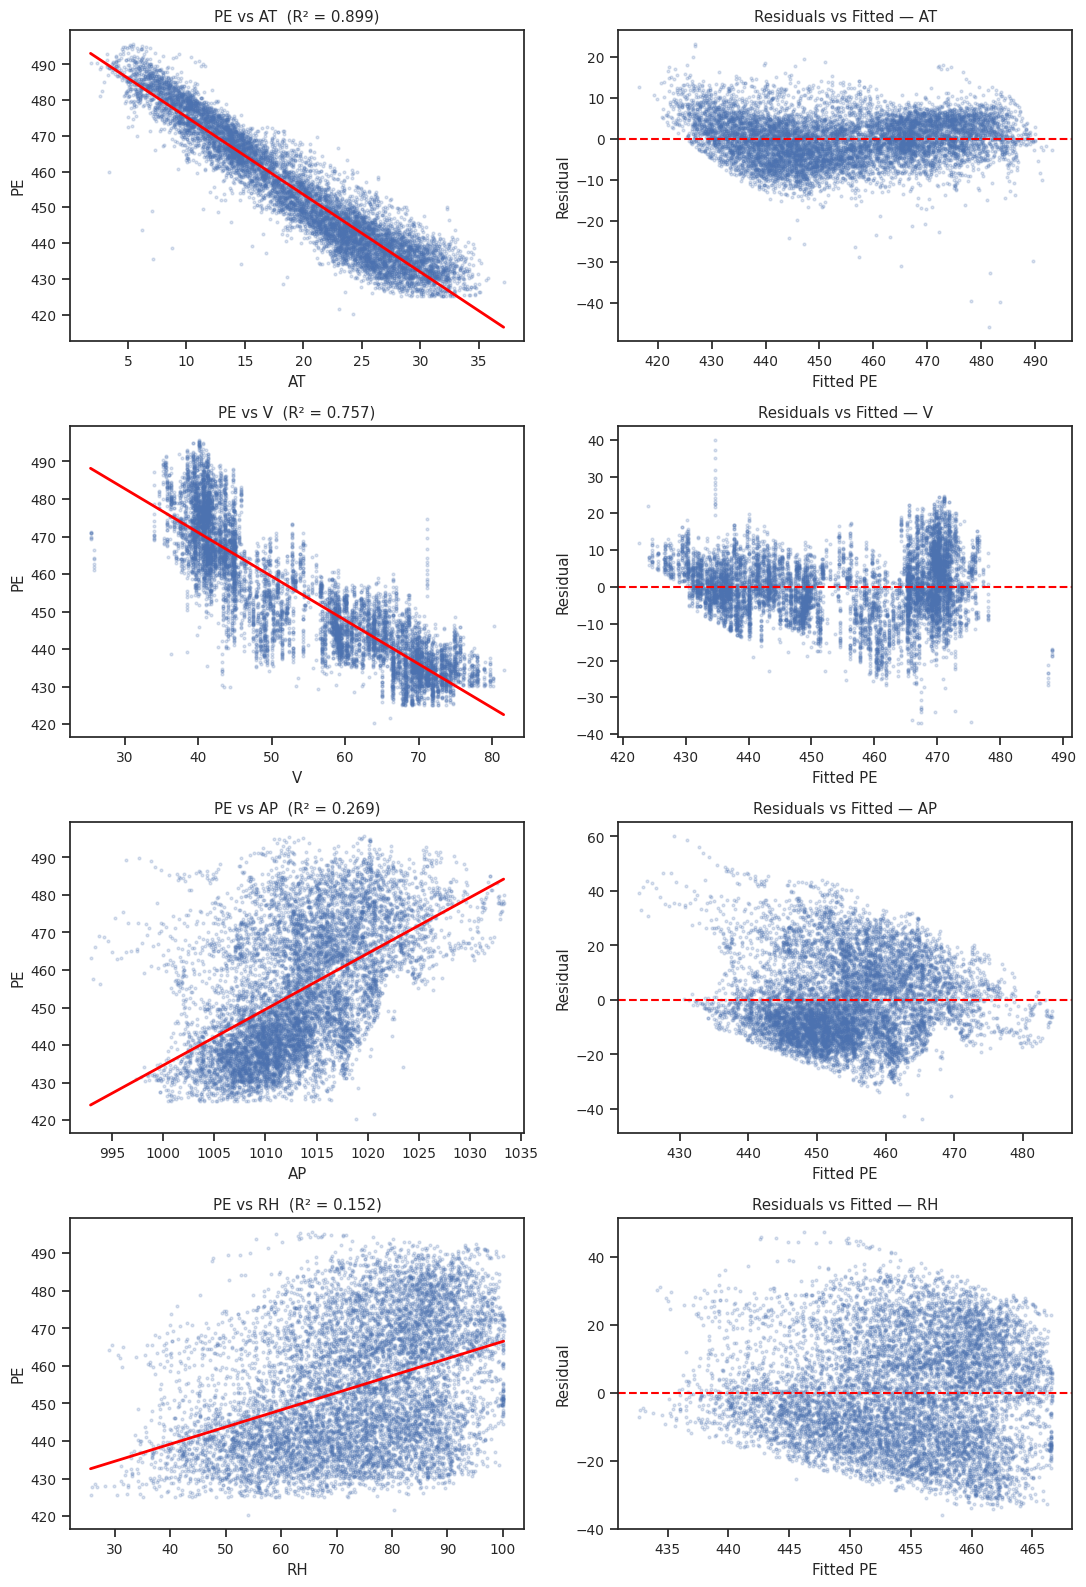

In [13]:
predictors = ['AT', 'V', 'AP', 'RH']

fig, axes = plt.subplots(len(predictors), 2, figsize=(11, 4*len(predictors)))

for i, col in enumerate(predictors):
    X = sm.add_constant(df[col])
    y = df['PE']
    model = sm.OLS(y, X).fit()

    print(f'===== PE ~ {col} =====')
    print(f'  coefficient   : {model.params[col]:.4f}')
    print(f'  intercept     : {model.params["const"]:.4f}')
    print(f'  p-value       : {model.pvalues[col]:.3g}')
    print(f'  R-squared     : {model.rsquared:.4f}')
    print(f'  t-statistic   : {model.tvalues[col]:.2f}\n')

    # left: data + fitted line
    axes[i, 0].scatter(df[col], df['PE'], s=4, alpha=0.2)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    y_pred = model.params['const'] + model.params[col] * x_range
    axes[i, 0].plot(x_range, y_pred, color='red', linewidth=2)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('PE')
    axes[i, 0].set_title(f'PE vs {col}  (R² = {model.rsquared:.3f})')

    # right: residuals vs fitted
    axes[i, 1].scatter(model.fittedvalues, model.resid, s=4, alpha=0.2)
    axes[i, 1].axhline(0, color='red', linestyle='--')
    axes[i, 1].set_xlabel('Fitted PE')
    axes[i, 1].set_ylabel('Residual')
    axes[i, 1].set_title(f'Residuals vs Fitted — {col}')

    # outlier check for this predictor
    infl = model.get_influence()
    student_resid = infl.resid_studentized_external
    cooks = infl.cooks_distance[0]
    n_extreme = np.sum(np.abs(student_resid) > 3)
    print(f'{col}: {n_extreme} points with |studentized residual| > 3, '
          f'max Cook\'s distance = {cooks.max():.4f}\n')

plt.tight_layout()
plt.show()

### d

In [14]:
X = sm.add_constant(df[['AT', 'V', 'AP', 'RH']])
y = df['PE']
model_full = sm.OLS(y, X).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:17:18   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

Based on the r-squared value, we can say that the predictors account for about 92.9% of the variance in PE. As expected, this is better than what we got using just one of the predictors. The p-values are all basically 0, so we can quite confidently reject the null hypothesis; all the relationships we've found are statistically significant.

### e

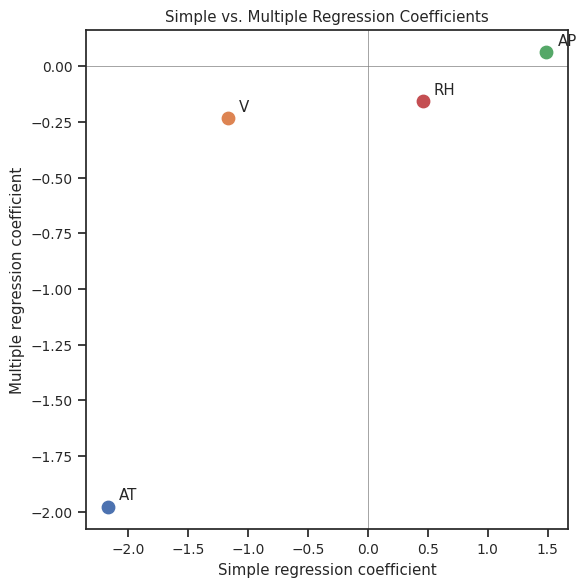

In [15]:
simple_coefs = {}
for col in predictors:
    X = sm.add_constant(df[col])
    m = sm.OLS(df['PE'], X).fit()
    simple_coefs[col] = m.params[col]

# multiple regression coefficients (from 1d)
Xf = sm.add_constant(df[predictors])
mf = sm.OLS(df['PE'], Xf).fit()
multi_coefs = mf.params[predictors]

# plot: x = simple coef, y = multiple coef, one point per predictor
fig, ax = plt.subplots(figsize=(6, 6))
for col in predictors:
    ax.scatter(simple_coefs[col], multi_coefs[col], s=80)
    ax.annotate(col, (simple_coefs[col], multi_coefs[col]),
                textcoords='offset points', xytext=(8, 5))
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Simple regression coefficient')
ax.set_ylabel('Multiple regression coefficient')
ax.set_title('Simple vs. Multiple Regression Coefficients')
plt.tight_layout()
plt.show()

### f

In [16]:
for col in ['AT', 'V', 'AP', 'RH']:
    x = df[col] - df[col].mean()

    X_cubic = pd.DataFrame({
        col:        x,
        col + '^2': x**2,
        col + '^3': x**3
    })
    X_cubic = sm.add_constant(X_cubic)
    model = sm.OLS(df['PE'], X_cubic).fit()

    print(f'===== PE ~ {col} + {col}^2 + {col}^3 =====')
    print(model.params)
    print('p-values:')
    print(model.pvalues)
    print(f'R-squared (cubic): {model.rsquared:.4f}')
    print()

===== PE ~ AT + AT^2 + AT^3 =====
const    452.708116
AT        -2.429734
AT^2       0.032554
AT^3       0.002675
dtype: float64
p-values:
const     0.000000e+00
AT        0.000000e+00
AT^2     3.311808e-231
AT^3     3.652185e-110
dtype: float64
R-squared (cubic): 0.9119

===== PE ~ V + V^2 + V^3 =====
const    451.213736
V         -1.250257
V^2        0.019177
V^3        0.000134
dtype: float64
p-values:
const     0.000000e+00
V         0.000000e+00
V^2      8.977010e-131
V^3       1.373489e-02
dtype: float64
R-squared (cubic): 0.7750

===== PE ~ AP + AP^2 + AP^3 =====
const    453.082345
AP         1.964663
AP^2       0.044238
AP^3      -0.004991
dtype: float64
p-values:
const    0.000000e+00
AP       0.000000e+00
AP^2     2.192722e-46
AP^3     2.123338e-67
dtype: float64
R-squared (cubic): 0.2975

===== PE ~ RH + RH^2 + RH^3 =====
const    454.442962
RH         0.530180
RH^2      -0.001325
RH^3      -0.000152
dtype: float64
p-values:
const     0.000000e+00
RH       9.648727e-152
RH^

AT, V, and P have quite statistically significant quadratic and cubic terms. High evidence of non-linearity. Things are a bit more ambiguous for RH--the cubic term is significant, but the quadratic isn't that different from the linear term.

### g

In [18]:
import statsmodels.formula.api as smf

In [19]:
model_interact = smf.ols('PE ~ (AT + V + AP + RH)**2', data=df).fit()
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:01:46   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Of the six interaction terms, four are statistically significant. Adding these interactions did improve the r-squared value, but not by very much.

### h

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [22]:
for col in ['AT', 'V', 'AP', 'RH']:
    df[col + '_c'] = df[col] - df[col].mean()

train, test = train_test_split(df, test_size=0.3, random_state=42)

# ---------- Model 1: plain linear model with all predictors ----------
m1 = smf.ols('PE ~ AT_c + V_c + AP_c + RH_c', data=train).fit()
train_mse1 = mean_squared_error(train['PE'], m1.predict(train))
test_mse1  = mean_squared_error(test['PE'],  m1.predict(test))
print('Model 1 (linear, all predictors)')
print(f'  train MSE: {train_mse1:.4f}   test MSE: {test_mse1:.4f}\n')



Model 1 (linear, all predictors)
  train MSE: 20.5808   test MSE: 21.2399



In [23]:
base_vars = ['AT_c', 'V_c', 'AP_c', 'RH_c']
interaction_terms = ['AT_c:V_c', 'AT_c:AP_c', 'AT_c:RH_c', 'V_c:AP_c', 'V_c:RH_c', 'AP_c:RH_c']
quad_terms = [f'I({v}**2)' for v in base_vars]

current_terms = interaction_terms + quad_terms

def build_formula(terms):
    return 'PE ~ ' + ' + '.join(base_vars + terms)

def norm(s):
    return s.replace(' ', '')

while True:
    formula = build_formula(current_terms)
    m = smf.ols(formula, data=train).fit()
    pvals = m.pvalues.drop('Intercept')
    norm_map = {norm(idx): idx for idx in pvals.index}
    removable_pvals = {t: pvals[norm_map[norm(t)]] for t in current_terms}
    worst_term = max(removable_pvals, key=removable_pvals.get)
    worst_p = removable_pvals[worst_term]
    if worst_p > 0.05:
        current_terms.remove(worst_term)
        print(f'Removing {worst_term} (p={worst_p:.4f})')
    else:
        break

final_formula = build_formula(current_terms)
print('\nFinal formula:', final_formula)
m2 = smf.ols(final_formula, data=train).fit()
print(m2.summary())

train_mse2 = mean_squared_error(train['PE'], m2.predict(train))
test_mse2  = mean_squared_error(test['PE'],  m2.predict(test))
print(f'\nModel 2 (pruned interactions+quadratics)')
print(f'  train MSE: {train_mse2:.4f}   test MSE: {test_mse2:.4f}')

Removing V_c:RH_c (p=0.8674)
Removing I(V_c**2) (p=0.6077)
Removing V_c:AP_c (p=0.3578)

Final formula: PE ~ AT_c + V_c + AP_c + RH_c + AT_c:V_c + AT_c:AP_c + AT_c:RH_c + AP_c:RH_c + I(AT_c**2) + I(AP_c**2) + I(RH_c**2)
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:28:17   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                

For model 1, we have: train MSE: 20.5808   test MSE: 21.2399

For model 2, we have: train MSE: 17.8908   test MSE: 18.6600

### i

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Best k (raw features):        k=5,  test MSE=15.7268
Best k (normalized features): k=4, test MSE=14.3057


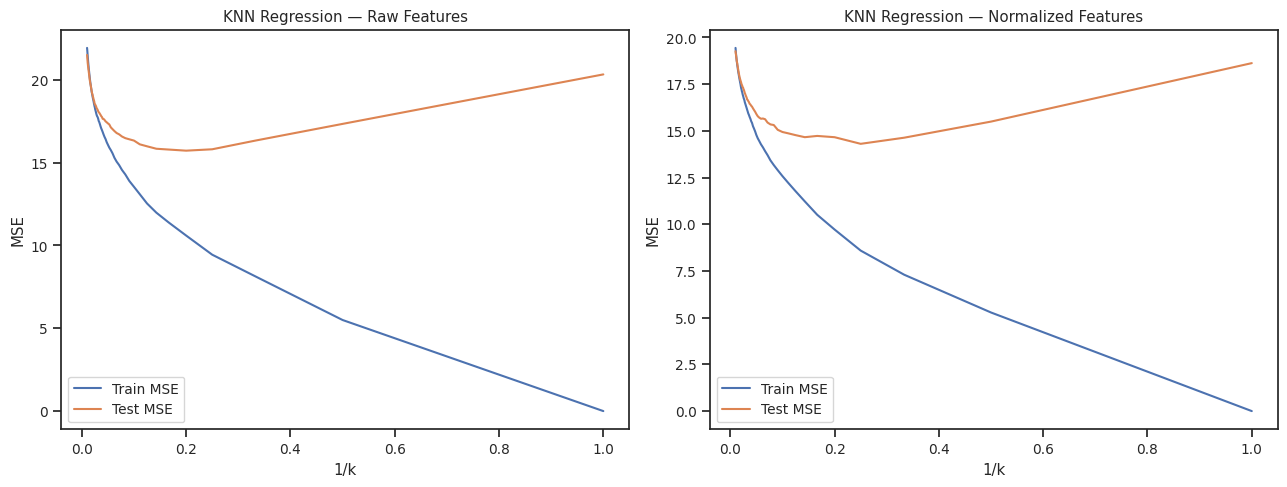

In [25]:
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm  = scaler.transform(X_test)

ks = range(1, 101)
raw_train_mse, raw_test_mse = [], []
norm_train_mse, norm_test_mse = [], []

for k in ks:
    knn_raw = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    raw_train_mse.append(mean_squared_error(y_train, knn_raw.predict(X_train)))
    raw_test_mse.append(mean_squared_error(y_test,  knn_raw.predict(X_test)))

    knn_norm = KNeighborsRegressor(n_neighbors=k).fit(X_train_norm, y_train)
    norm_train_mse.append(mean_squared_error(y_train, knn_norm.predict(X_train_norm)))
    norm_test_mse.append(mean_squared_error(y_test,  knn_norm.predict(X_test_norm)))

best_k_raw  = list(ks)[np.argmin(raw_test_mse)]
best_k_norm = list(ks)[np.argmin(norm_test_mse)]
print(f'Best k (raw features):        k={best_k_raw},  test MSE={min(raw_test_mse):.4f}')
print(f'Best k (normalized features): k={best_k_norm}, test MSE={min(norm_test_mse):.4f}')

inv_k = 1 / np.array(list(ks))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(inv_k, raw_train_mse, label='Train MSE')
axes[0].plot(inv_k, raw_test_mse, label='Test MSE')
axes[0].set_xlabel('1/k'); axes[0].set_ylabel('MSE')
axes[0].set_title('KNN Regression — Raw Features')
axes[0].legend()

axes[1].plot(inv_k, norm_train_mse, label='Train MSE')
axes[1].plot(inv_k, norm_test_mse, label='Test MSE')
axes[1].set_xlabel('1/k'); axes[1].set_ylabel('MSE')
axes[1].set_title('KNN Regression — Normalized Features')
axes[1].legend()

plt.tight_layout()
plt.show()

### j

Best linear model's MSE was 18.66. Best KNN model's MSE was 14.31. So it's pretty clear that KNN is the better option here, but what it gains in accuracy it sacrifices in interpretability. The linear model helps you know for sure how much PE changes AT, by what degrees, etc. KNN doesn't do that.

## 2.4.1

### a

Flexible would be better. A flexible method could represent a complex relationship without running the risk of overfitting.

### b

Inflexible would be better here. If you have lots of predictors but not many observations, flexible methods will overfit or introduce a bunch of noise into the representation.

### c

Flexible is better. An inflexible method wouldn't be able to overcome the inherent bias built into it about the data's shape and behaviour.

### d

Inflexible is better. A flexible method will just take the noise and overfit to it, skewing the representation completely.

## 2.4.7

### a

X1 = 3

X2 = 2

X3 = √10

X4 = √5

X5 = √2

X6 = √3

### b

The closest would be X5, as √2 is closest to 1, so we pick green.

### c

We can go for X5, X6, and X2. That's 2 reds and 1 green, so we pick red after looking at the majority.

### d

It should be small. A small K makes the decision boundary less linear, because it's so much more dependent on 1 or 2 neighbors rather than 20 or 30 or whatever the larger K would be.